In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image



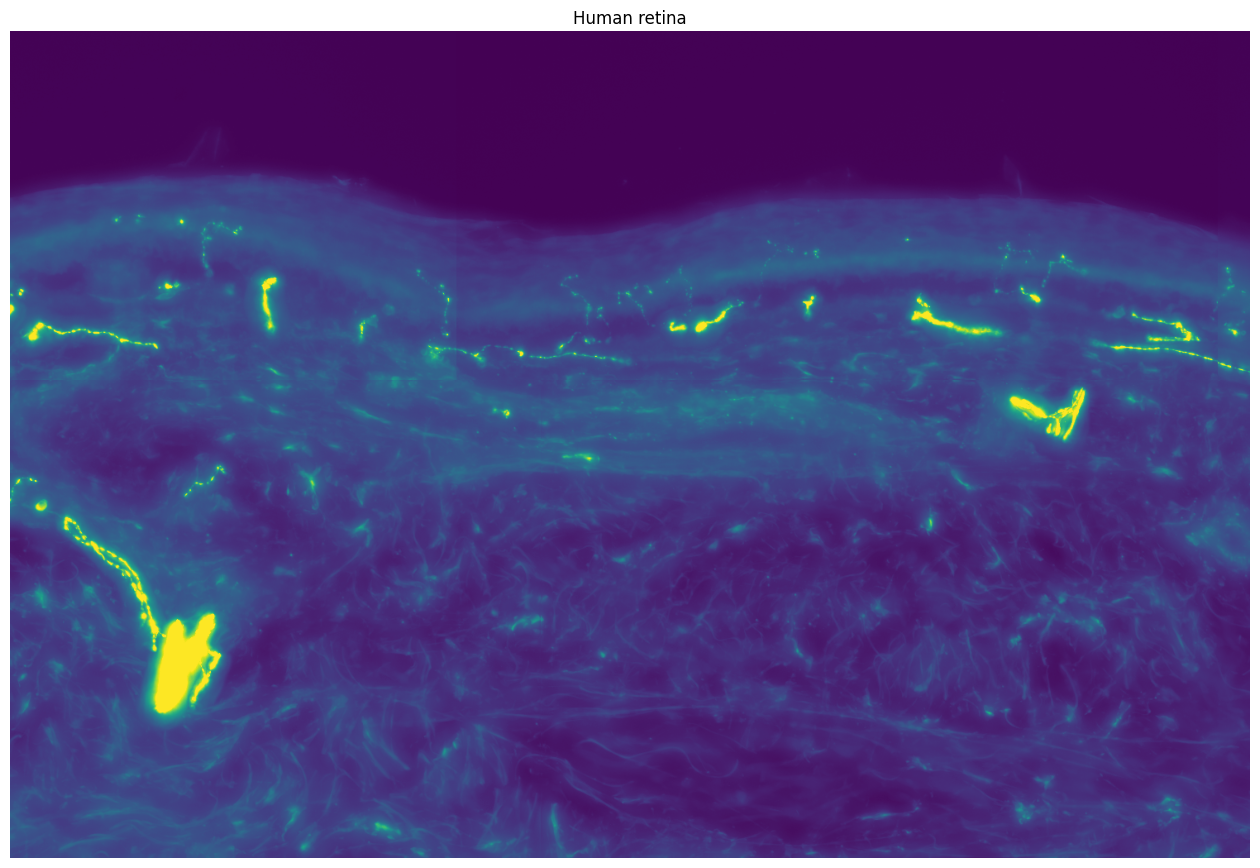

In [36]:
# 讀取圖像檔案 (請將 'image.jpg' 替換為您的檔案路徑)
img = np.array(Image.open('../data/S1585-2_a/image.png'))

# 提取綠色通道 (RGB 中的 G 通道)
green_channel = img[:, :, 1]

# clip 小區域
green_channel = green_channel[500:1500,2225:3725]

# # 進行 rolling ball 背景校正
# background = ski.restoration.rolling_ball(green_channel, radius=3)
# green_channel = green_channel - background

# # 正規化到 0-1 範圍
# green_channel = (green_channel - green_channel.min()) / (green_channel.max() - green_channel.min())

_, ax = plt.subplots(figsize=(16, 16))
ax.imshow(green_channel)
ax.set_axis_off()
_ = ax.set_title('Human retina')

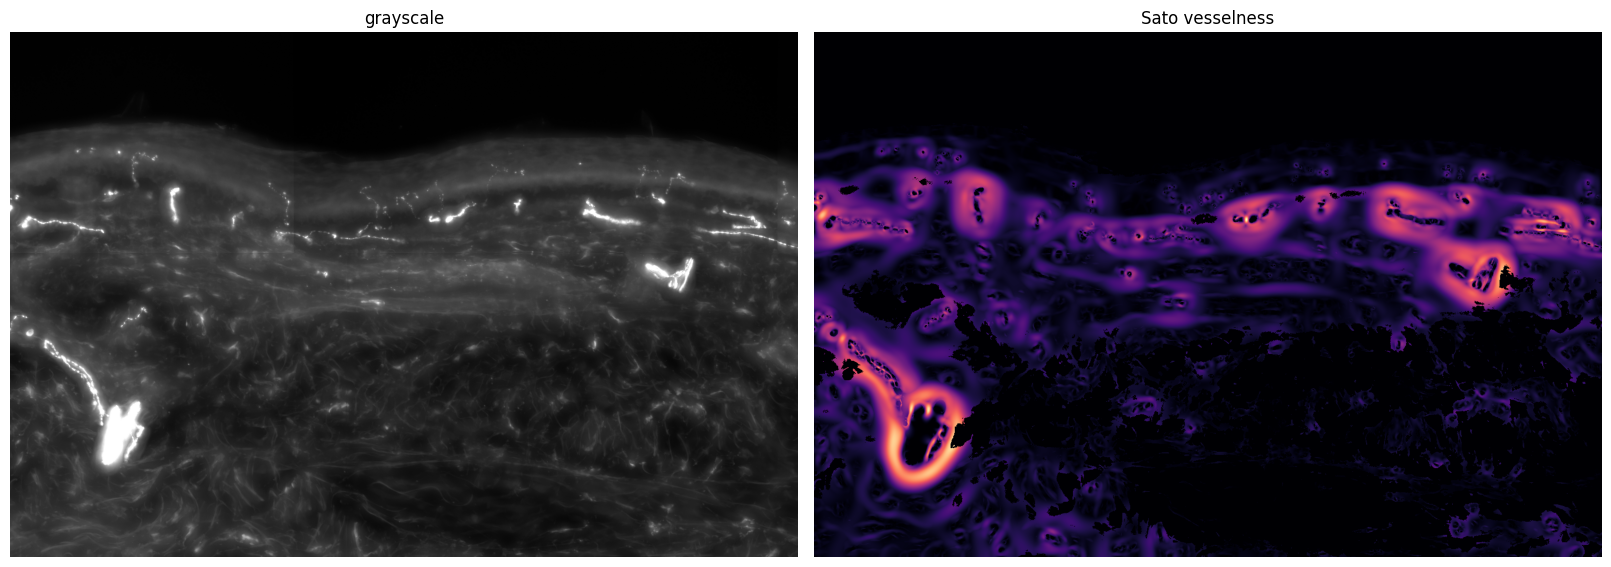

In [ ]:
t0, t1 = ski.filters.threshold_multiotsu(green_channel, classes=3)
mask = green_channel > t0
vessels = ski.filters.sato(green_channel, sigmas=range(1, 6)) * mask

_, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), constrained_layout=True)
axes[0].imshow(green_channel, cmap='gray')
axes[0].set_axis_off()
axes[0].set_title('grayscale')
axes[1].imshow(vessels, cmap='magma')
axes[1].set_axis_off()
_ = axes[1].set_title('Sato vesselness')

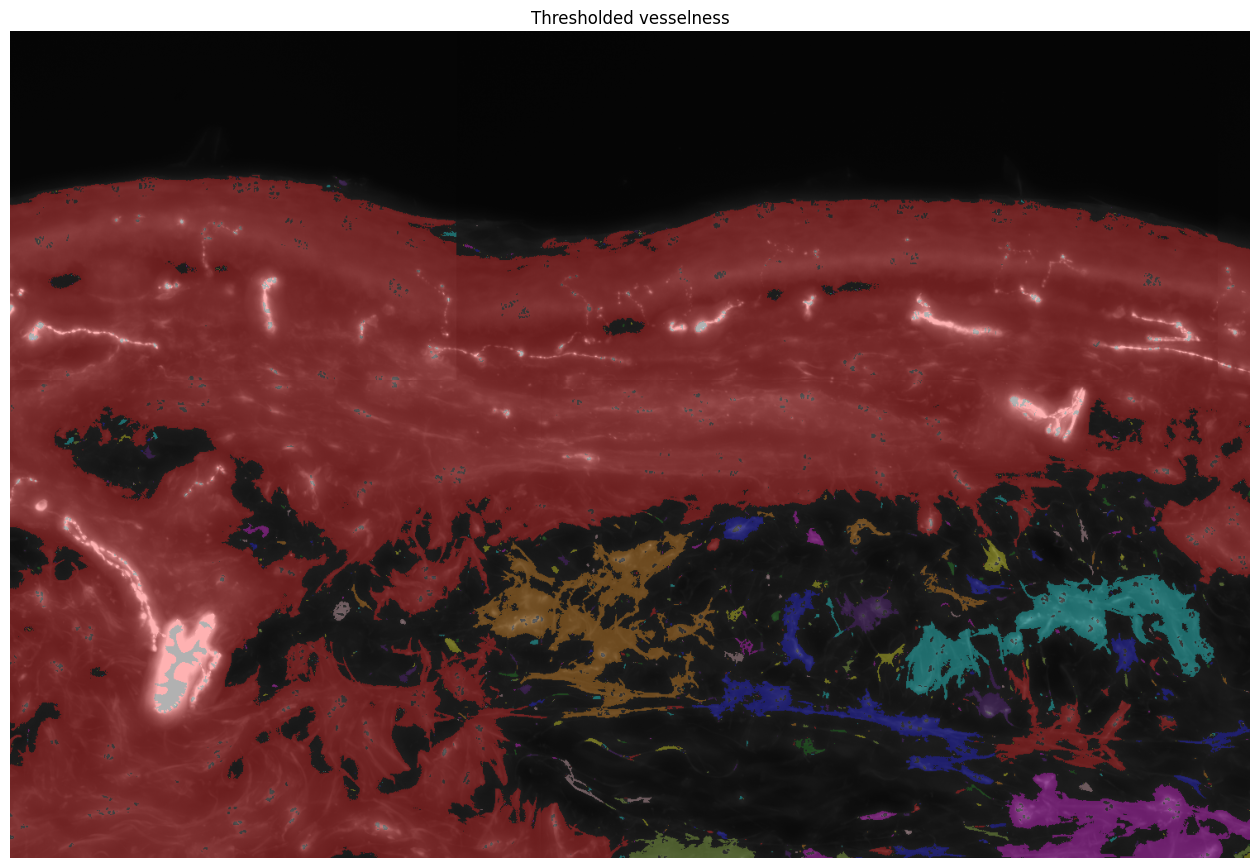

In [38]:
thresholded = ski.filters.apply_hysteresis_threshold(vessels, 0.01, 0.03)
labeled = ndi.label(thresholded)[0]

_, ax = plt.subplots(figsize=(16, 16))
ax.imshow(ski.color.label2rgb(labeled, green_channel))
ax.set_axis_off()
_ = ax.set_title('Thresholded vesselness')